#Basic codes

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
import cv2
from scipy import signal
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from scipy import stats
from scipy.stats import t
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [8]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [9]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/0/"
subhalo = get(sub_url)


#New codes

In [10]:
sub_path = '/content/drive/MyDrive/sub'

all_bhmdot = []
all_sfr = []

for folder_num in range(100):
    save_file_path = os.path.join(sub_path, f'sb{folder_num}.npz')

    if os.path.exists(save_file_path):
        loaded_data = np.load(save_file_path)
        all_bhmdot.append(loaded_data['bhmdot'])
        all_sfr.append(loaded_data['sfr'])
    else:
        print(f"File not found {folder_num}: {save_file_path}")

if all_bhmdot and all_sfr:
    final_bhmdot = np.concatenate(all_bhmdot)
    final_sfr = np.concatenate(all_sfr)

    print(f"Loaded the data from {len(all_bhmdot)} files.")

    print(f"First 10 elements of final_bhmdot: {final_bhmdot[:10]}")

    print(f"First 10 elements of final_sfr: {final_sfr[:10]}")
else:
    print("No data files were found or loaded.")

Loaded the data from 100 files.
First 10 elements of final_bhmdot: [0.00351652 0.0166792  0.00102882 0.00874955 0.00163583 0.00256499
 0.00037256 0.00249654 0.00077815 0.00277787]
First 10 elements of final_sfr: [410.991     61.4731    19.4075    18.2909     6.63607    7.76953
   0.433356   4.90325    4.00612    1.93112 ]


In [11]:
bhl = 1e4*final_bhmdot[(final_bhmdot != -1) & (final_bhmdot != 0)]
sfrl = final_sfr[(final_sfr != -1) & (final_sfr != 0)].tolist()

bins = np.logspace(-15, 5, 100)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

bh_median = np.median(bhl)
sfr_median = np.median(sfrl)

bh_mean = np.mean(bhl)
sfr_mean = np.mean(sfrl)

bh_std = np.std(bhl)
sfr_std = np.std(sfrl)

counts3, _ = np.histogram(bh_median, bins=bins)
counts4, _ = np.histogram(sfr_median, bins=bins)
counts5, _ = np.histogram(bh_mean, bins=bins)
counts6, _ = np.histogram(sfr_mean, bins=bins)

/tmp/ipykernel_8652/1172040491.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])


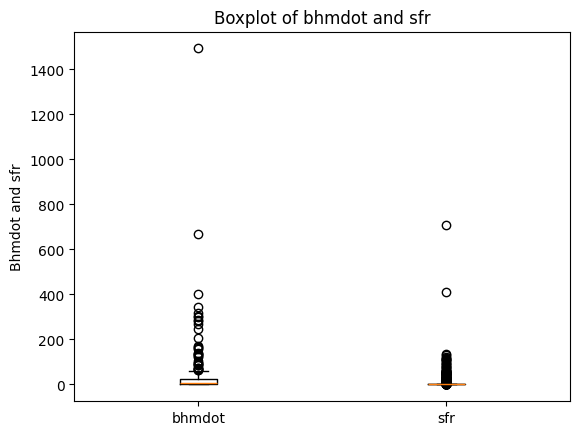

In [12]:
plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])
plt.title('Boxplot of bhmdot and sfr')
plt.ylabel('Bhmdot and sfr')
plt.show()

/tmp/ipykernel_8652/4140522431.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])


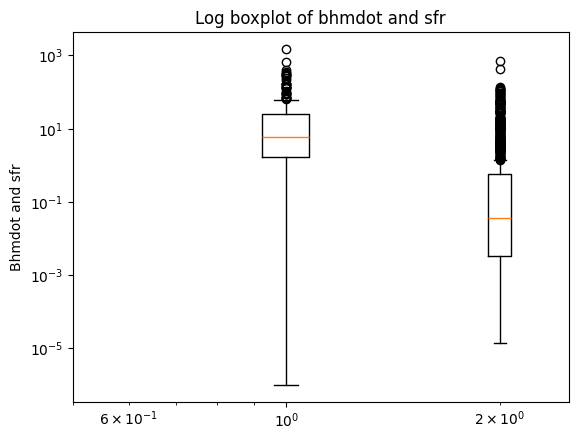

In [13]:
plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])
plt.title('Log boxplot of bhmdot and sfr')
plt.ylabel('Bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [14]:
bins = np.logspace(-7, 5, 30)

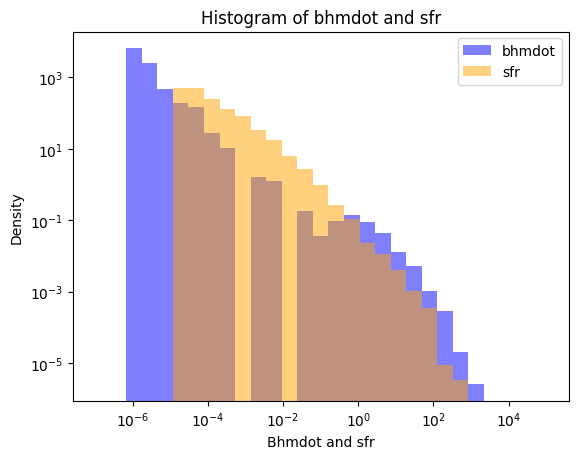

In [15]:
plt.hist(bhl, bins=bins, alpha=0.5, label='bhmdot', color='blue', density=True)
plt.hist(sfrl, bins=bins, alpha=0.5, label='sfr', color='orange', density=True)
plt.title('Histogram of bhmdot and sfr')
plt.xlabel('Bhmdot and sfr')
plt.ylabel('Density')
plt.yscale('log')
plt.xscale('log')
plt.legend()

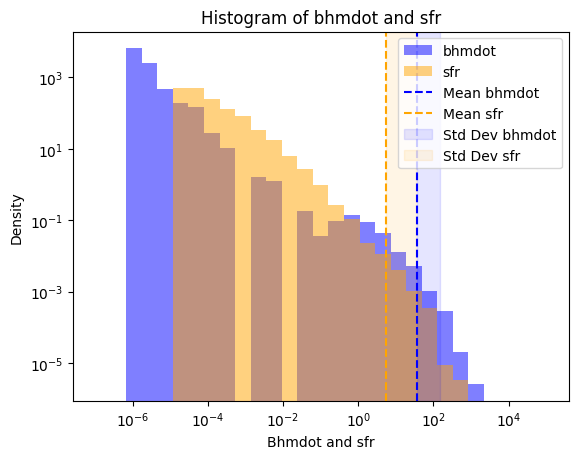

In [17]:
plt.hist(bhl, bins=bins, alpha=0.5, label='bhmdot', color='blue', density=True)
plt.hist(sfrl, bins=bins, alpha=0.5, label='sfr', color='orange', density=True)

plt.axvline(bh_mean, color='blue', linestyle='--', label='Mean bhmdot')
plt.axvline(sfr_mean, color='orange', linestyle='--', label='Mean sfr')

plt.axvspan(bh_mean , bh_mean + bh_std, alpha=0.1, color='blue', label='Std Dev bhmdot')
plt.axvspan(sfr_mean , sfr_mean + sfr_std, alpha=0.1, color='orange', label='Std Dev sfr')


plt.title('Histogram of bhmdot and sfr')
plt.xlabel('Bhmdot and sfr')
plt.ylabel('Density')

plt.yscale('log')
plt.xscale('log')
plt.legend()

In [18]:
t_stat, p_val = stats.ttest_ind(bhl, sfrl)

print(f"t_stat: {t_stat: .2f}")
print(f"p-val: {p_val: .3f}")

alpha = 0.05
if p_val < alpha:
    print(f"Since p-value ({p_val: .3f} is < than alpha ({alpha})), we reject the null hypothesis")
elif p_val > alpha:
    print(f"Since p-value ({p_val: .3f} is > than alpha ({alpha})), we accept the null hypothesis")


t_stat:  8.15
p-val:  0.000
Since p-value ( 0.000 is < than alpha (0.05)), we reject the null hypothesis


In [21]:
bhl2 = np.zeros(len(sfrl))
bhl2[:len(bhl)] = bhl
np.corrcoef(sfrl, bhl2)

array([[1.        , 0.00249419],
       [0.00249419, 1.        ]])

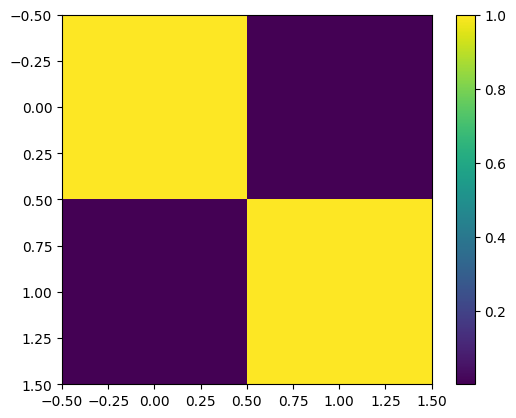

In [31]:
corr = np.corrcoef(sfrl, bhl2)
plt.imshow(corr)
plt.colorbar()

In [32]:
signal.correlate(sfrl, bhl2, mode='full')

array([0.        , 0.        , 0.        , ..., 0.12263877, 0.105826  ,
       0.02062801])